In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pytz
import os
from glob import glob
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import summary_table
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LogisticRegression
from itertools import product
from sklearn.linear_model import LogisticRegression

In [2]:
root="/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/"  # Change to user directory
fldr=root+"supportingData/"
dat = np.load(fldr+"rmobilizations.npy")
# For full dataset, load raw mobilizations (rmobilizations.npy)
print(dat.shape)
mobilizations=dat[0,:]
flows=dat[1,:]
omega0=dat[2,:]
stays=dat[3,:]

(4, 64407)


In [3]:
mobilizations.sum()

1139.0

In [4]:
print(mobilizations[(omega0 > 10**1)].mean())
print(mobilizations[(omega0 < 10**-2)].mean())

0.026473629782833505
0.008720684108034883


/home/shan/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['fit_intercept']
  warnings.warn(msg, ValueWarning)


Optimization terminated successfully.
         Current function value: 0.078836
         Iterations 8


/home/shan/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['fit_intercept']
  warnings.warn(msg, ValueWarning)


                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                64407
Model:                          Logit   Df Residuals:                    64404
Method:                           MLE   Df Model:                            2
Date:                Tue, 04 Aug 2026   Pseudo R-squ.:                  0.1131
Time:                        11:18:57   Log-Likelihood:                -5077.6
converged:                       True   LL-Null:                       -5724.8
Covariance Type:            nonrobust   LLR p-value:                8.287e-282
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0752      0.010      7.332      0.000       0.055       0.095
x2            -0.0723      0.002    -42.829      0.000      -0.076      -0.069
const         -3.7247      0.033   -113.662      0.0

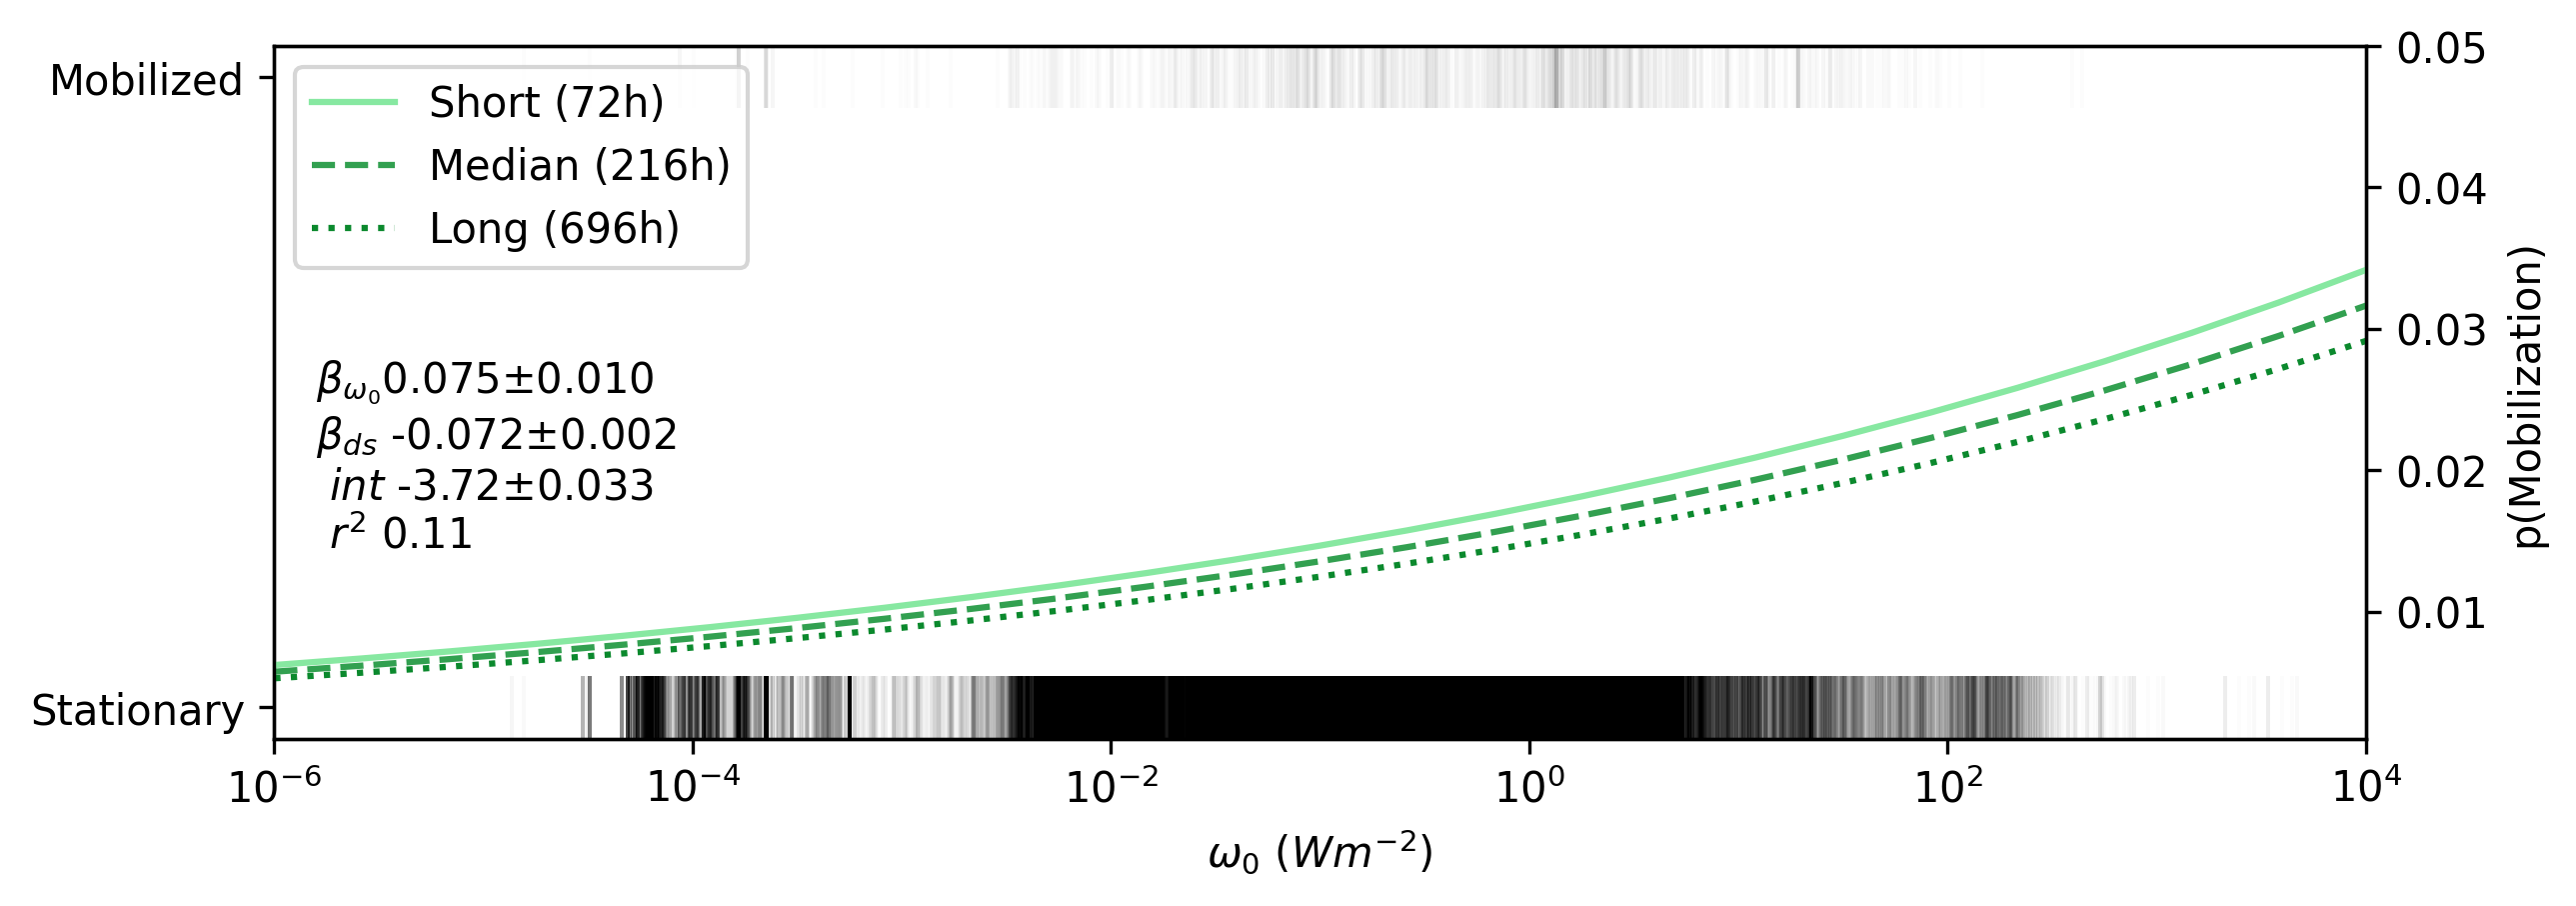

In [5]:
plot=True
low,high=1e-6,1e4
if plot:
    fig,ax=plt.subplots(1,1,figsize=(9,3),dpi=300)        
    axb=ax.twinx()
R = np.arange(np.log(1e-4),np.log(1e3),1)

if plot:
    ax.plot(omega0,mobilizations.astype(int),color='k',marker="|",ms=15,ls='none',alpha=0.01)
    ax.set_xscale('log')
    ax.set_yticks([0,1])
    ax.set_yticklabels(["Stationary","Mobilized"])
    ax.set_xlabel("$\omega_0$ ($W m^{-2}$)")

# Without lodging
no_lodging=False
if no_lodging:
    X=np.stack((np.log(omega0),np.ones_like(omega0))).T
    y=mobilizations.astype(int)
    
    model = sm.Logit(y,X,missing="drop").fit()
    print(model.summary())
    print(dir(model))
    
    X_plot=np.logspace(np.log(low),np.log(high),25,base=np.exp(1))
    cs="#87e8a1 #32a050 #0b892d".split()
    X_pred=np.stack((X_plot,np.exp(1)*np.ones_like(X_plot))).T
    y_prob=model.predict(np.log(X_pred))
    
    if plot:
        axb.plot(X_plot,y_prob,ls='--',color='b',label="No lodging")        
    
    
    if plot:
        axb.text(0.20,0.55,r"$\beta_{\omega_0}$"+"{:0.3f}$\pm${:0.3f}\n".format(model.params[0],model.bse[0])
                 +"$int$ {:0.2f}$\pm${:0.3f} \n $r^2$ {:0.2f}".format(model.params[1],model.bse[1],model.prsquared),
                transform=ax.transAxes,fontsize=8,va="top")

# With lodging
X=np.stack((np.log(omega0),np.log(stays),np.ones_like(omega0))).T
y=mobilizations.astype(int)

model = sm.Logit(y,X,missing="drop",fit_intercept=True).fit()
print(model.summary())

durations=stays[mobilizations==1]
durations=durations[durations>1]
q1,q2,q3=np.quantile(durations,[0.25,0.5,0.75])
print(q1,q2,q3)

X_plot=np.logspace(np.log(low),np.log(high),25,base=np.exp(1))
cs="#87e8a1 #32a050 #0b892d".split()
def mod(X,p):
    return 1./(1. + np.exp( - (p[2] + p[0] * np.log(X[:,0]) + p[1] * np.log(X[:,1]))))

def mod2(X,p):
    return 1./(1+np.exp(-np.log(X) @ p))
    
for n,c,q,l in zip("Short ({:0.0f}h),Median ({:0.0f}h),Long ({:0.0f}h)".format(q1,q2,q3).split(','),cs,[q1,q2,q3],["-","--",":"]):
    X_pred=np.stack((X_plot,q*np.ones_like(X_plot),np.exp(1)*np.ones_like(X_plot))).T
    y_prob=model.predict(np.log(X_pred))

    if plot:
        axb.plot(X_plot,y_prob,ls=l,color=c,label=n)
        
        #axb.plot(X_plot,mod2(X_pred,model.params),'k-')

if plot:
    axb.text(0.02,0.55,r"$\beta_{\omega_0}$"+"{:0.3f}$\pm${:0.3f}\n".format(model.params[0],model.bse[0])
             +r"$\beta_{ds}$"
             +" {:0.3f}$\pm${:0.3f} \n $int$ {:0.2f}$\pm${:0.3f} \n $r^2$ {:0.2f}".format(model.params[1],model.bse[1],model.params[2],model.bse[2],
                                                                                                   model.prsquared),
            transform=ax.transAxes,fontsize=10,va="top")

    axb.set_ylabel("p(Mobilization)")
    axb.set_ylim((1e-3,5e-2))
    ax.set_xlim((low,high))
    axb.legend(loc=2)

Above shows the best estimates of the Logisitic Regression.  There is substantial uncertainty on each of the parameter estimates that can be accounted for by estimating the influence of parameteric errors on the outcomes.  We estimate high and low bounds on the relationship by perturbing the coefficients along according to the uncertainty in the predictor (_V_) for each combination of _x_ ($\omega_0$ and $ds$):

$V = x^T \Sigma_\beta x $
where $\Sigma_\beta$ is the covariance matrix of the computed model.  We then calculate the upper and lower bounds of P(M):

$P(M)_L\ =\ logit^{-1}(\beta^T x - 1.96\sqrt{V}) $

$P(M)_U\ =\ logit^{-1}(\beta^T x + 1.96\sqrt{V}) $


Below we show the influence of this uncertainty for the median value of the duration stationary.

72.0 216.0 696.0


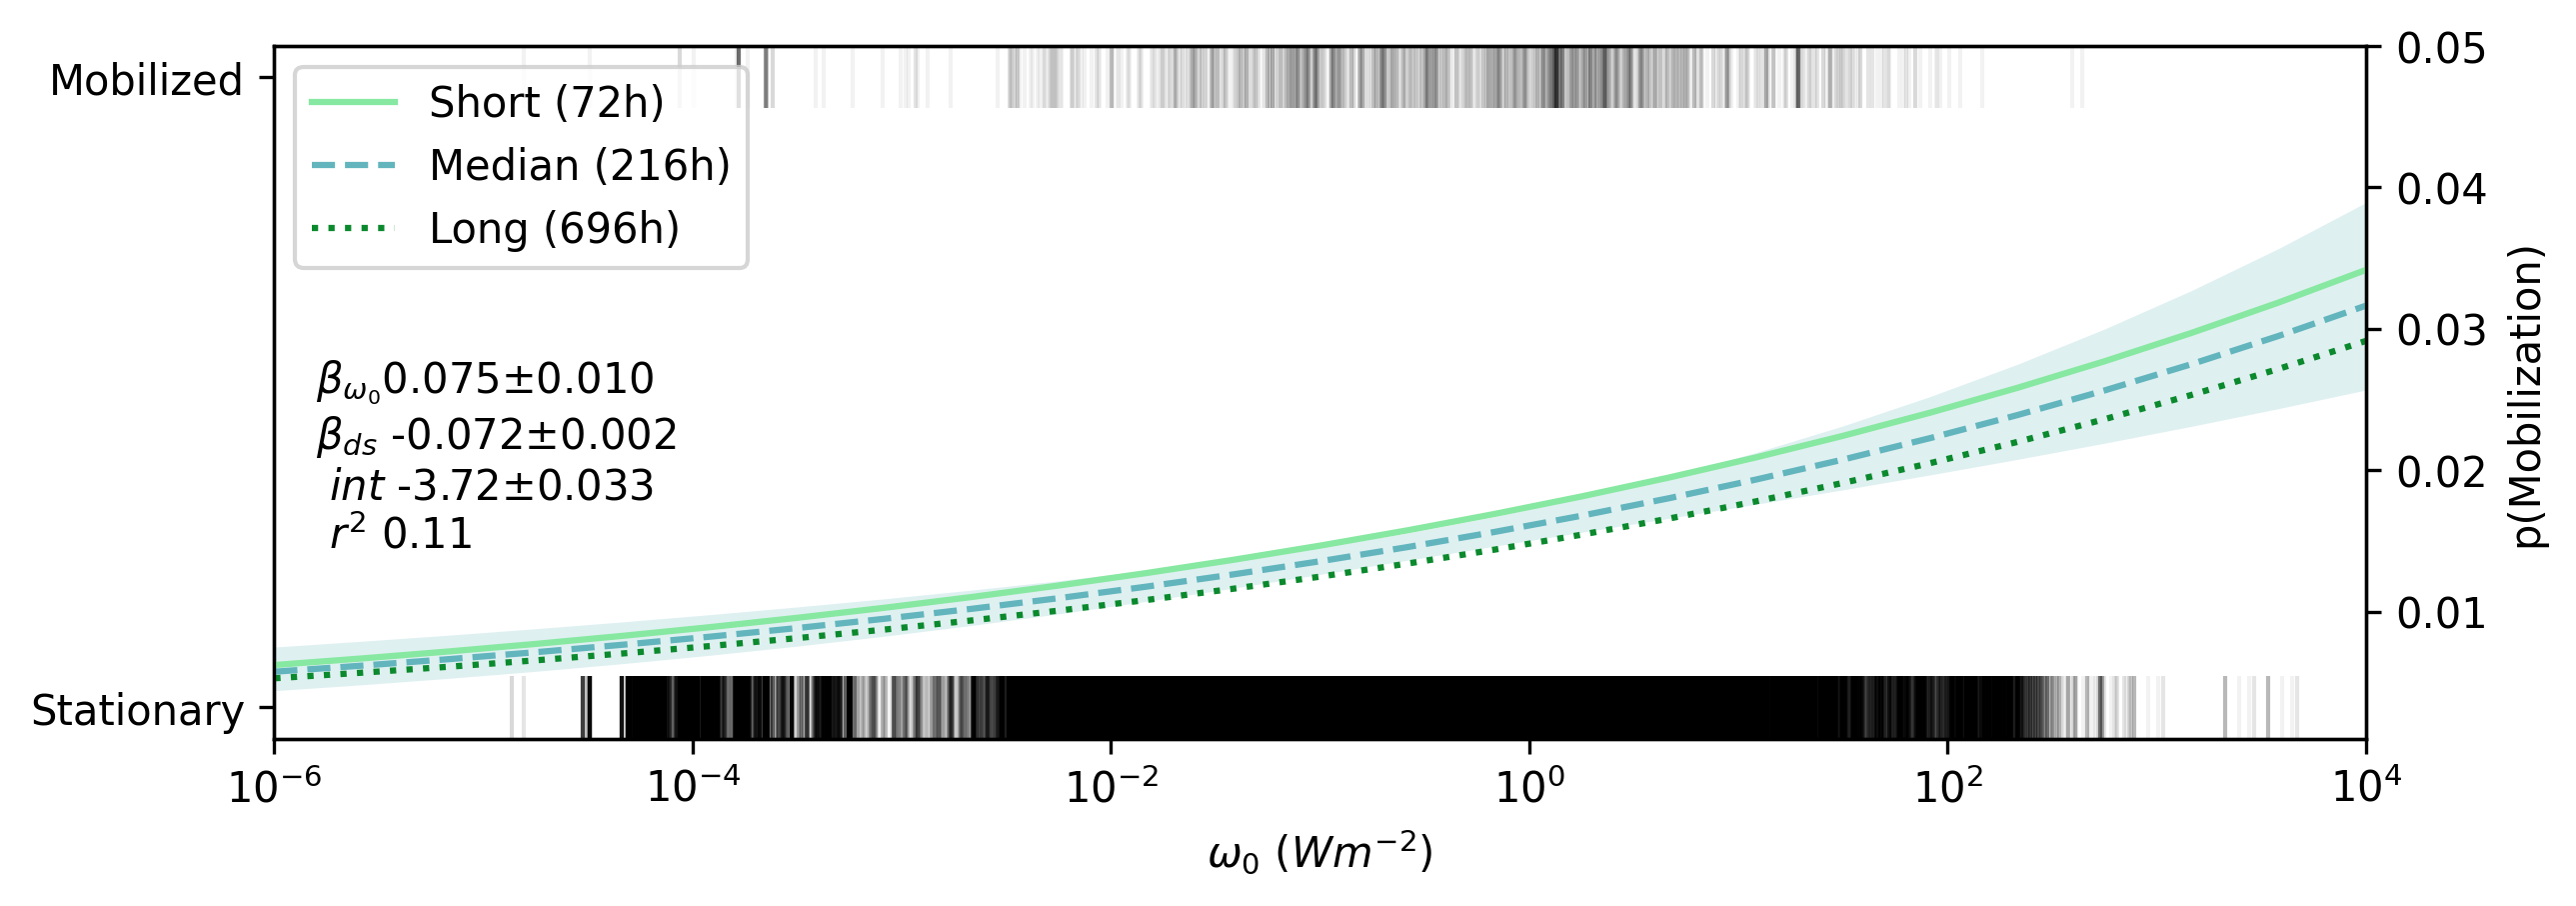

In [8]:
plot=True
low,high=1e-6,1e4
if plot:
    fig,ax=plt.subplots(1,1,figsize=(9,3),dpi=300)        
    axb=ax.twinx()
R = np.arange(np.log(1e-4),np.log(1e3),1)

if plot:
    ax.plot(omega0,mobilizations.astype(int),color='k',marker="|",ms=15,ls='none',alpha=0.05)
    ax.set_xscale('log')
    ax.set_yticks([0,1])
    ax.set_yticklabels(["Stationary","Mobilized"])
    ax.set_xlabel("$\omega_0$ ($W m^{-2}$)")


# With lodging
X=np.stack((np.log(omega0),np.log(stays),np.ones_like(omega0))).T
y=mobilizations.astype(int)

durations=stays[mobilizations==1]
durations=durations[durations>1]
q1,q2,q3=np.quantile(durations,[0.25,0.5,0.75])
print(q1,q2,q3)

X_plot=np.logspace(np.log(low),np.log(high),25,base=np.exp(1))
cs="#87e8a1 #62b5bd #0b892d".split()  # swapped #62b5bd for #32a050
for n,c,q,l in zip("Short ({:0.0f}h),Median ({:0.0f}h),Long ({:0.0f}h)".format(q1,q2,q3).split(','),cs,[q1,q2,q3],["-","--",":"]):
    X_pred=np.stack((X_plot,q*np.ones_like(X_plot),np.exp(1)*np.ones_like(X_plot))).T
    y_prob=model.predict(np.log(X_pred))
    SigB=model.cov_params()
    # These two estimates of the uncertainty are equivalent
    err = 1.96 * np.sqrt( np.einsum('ij,jk,ik->i',np.log(X_pred), SigB,np.log(X_pred)))
    err = 1.96 * np.sqrt( np.sum( (np.log(X_pred) @ SigB) * np.log(X_pred),axis=1))
    
    #print( 1./(1+np.exp( -np.log(X_pred) @ model.params - err) ) - 1./(1+np.exp( -np.log(X_pred) @ model.params + err) ))
    if plot:
        axb.plot(X_plot,y_prob,ls=l,color=c,label=n)
        if l == "--":
            axb.fill_between(X_plot,y1=1./(1+np.exp(-np.log(X_pred) @ model.params - err)), y2=1./(1.+np.exp(-np.log(X_pred) @ model.params + err)),
                             color=c,alpha=0.2,lw=0)
        

if plot:
    axb.text(0.02,0.55,r"$\beta_{\omega_0}$"+"{:0.3f}$\pm${:0.3f}\n".format(model.params[0],model.bse[0])
             +r"$\beta_{ds}$"
             +" {:0.3f}$\pm${:0.3f} \n $int$ {:0.2f}$\pm${:0.3f} \n $r^2$ {:0.2f}".format(model.params[1],model.bse[1],model.params[2],model.bse[2],
                                                                                                   model.prsquared),
            transform=ax.transAxes,fontsize=10,va="top")

    axb.set_ylabel("p(Mobilization)")
    axb.set_ylim((1e-3,5e-2))
    ax.set_xlim((low,high))
    axb.legend(loc=2)


Calculate and show the confusion matrix of the regression. Predicted mobilization is completely dependent on what we select for a mobilizatoin threshold, since there are no cases where we see greater than 50% probability by the model.  We will test a range of values from 0.5 to 5%.

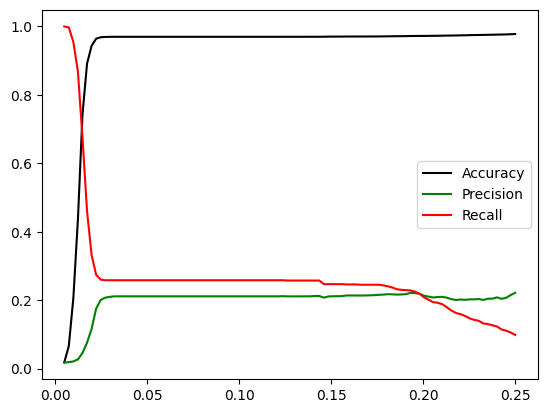

In [54]:
T=np.linspace(0.005,0.25,100)
ACC,PRC,RCL=[],[],[]
for t in T:
    yp=model.predict(X)>t
    TP = ((yp == 1) & (y == 1)).sum()
    TN = ((yp == 0) & (y == 0)).sum()
    FP = ((yp == 1) & (y == 0)).sum()
    FN = ((yp == 0) & (y == 1)).sum()
    ACC.append(  (TP+TN) / yp.shape[0] )
    PRC.append( TP / (TP + FP) )
    RCL.append( TP / (TP + FN) )

plt.plot(T,ACC,'k-',label='Accuracy')
plt.plot(T,PRC,'g-',label='Precision')
plt.plot(T,RCL,'r-',label='Recall')
plt.legend()

Now we retrain the model while balancing the class and test again over the same range of mobilization thresholds.

In [43]:
from statsmodels.genmod import families

In [49]:
X=np.stack((np.log(omega0),np.log(stays),np.ones_like(omega0))).T
y=mobilizations.astype(int)
W=np.ones_like(y,dtype=float)
W[y==1]*=10.
balanced_model = sm.GLM(y,X,missing="drop",family=families.Binomial(),freq_weights=W).fit()
print(balanced_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                64407
Model:                            GLM   Df Residuals:                    74655
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -27062.
Date:                Tue, 04 Aug 2026   Deviance:                       54124.
Time:                        12:00:48   Pearson chi2:                 7.06e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1392
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0888      0.004     23.621      0.0

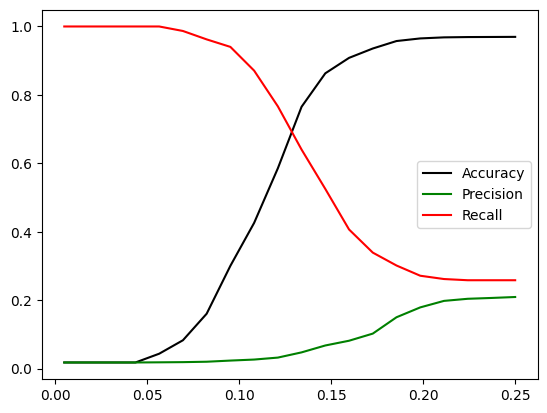

In [55]:
T=np.linspace(0.005,0.25,20)
ACC,PRC,RCL=[],[],[]
for t in T:
    yp=balanced_model.predict(X)>t
    TP = ((yp == 1) & (y == 1)).sum()
    TN = ((yp == 0) & (y == 0)).sum()
    FP = ((yp == 1) & (y == 0)).sum()
    FN = ((yp == 0) & (y == 1)).sum()
    ACC.append(  (TP+TN) / yp.shape[0] )
    PRC.append( TP / (TP + FP) )
    RCL.append( TP / (TP + FN) )

plt.plot(T,ACC,'k-',label='Accuracy')
plt.plot(T,PRC,'g-',label='Precision')
plt.plot(T,RCL,'r-',label='Recall')
plt.legend()

The parameters of the logistic regression are needed to be introduced to the probalistic model.  These are:

In [8]:
print(model.params)

[ 0.07516407 -0.07234005 -3.72466841]


And the covariance matrix which is:

In [9]:
print(model.cov_params())

[[1.05086101e-04 2.80437507e-07 9.96094049e-05]
 [2.80437507e-07 2.85292149e-06 9.13180423e-06]
 [9.96094049e-05 9.13180423e-06 1.07385297e-03]]
